## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence

## Initialization and Analysis of Axion Parameter Dependence

In this notebook, we analyze the dependence of parameters **A(m_a)**, **b(m_a)**, and **μ(m_a)** on axion mass **m_a** 
after selecting a specific axion production channel. The goal is to fit functions to describe these dependencies and evaluate their accuracy.

#### **Key Observations:**
1. **Polynomial Fit Behavior:**
   - The polynomial fits **A(log(m_a))**, **b(log(m_a))**, and **μ(log(m_a))** work well **within the provided mass range**:  
     **[0.00569 eV, 5.69 eV]** (as given by Maxim's distribution data).  
   - However, **extrapolation beyond this range is highly unreliable**. The polynomial fit becomes unstable and produces unrealistic values.
2. **Function-Based Fit (Model-Driven Approach):**
   - We implement model-based fitting functions to mimic the observed behavior of the parameters.  
   - However, some challenges remain:
     - The **μ(m_a) dependence** shows discrepancies that require further investigation.
     - The **A(m_a) fit struggles at larger masses**, especially outside the provided dataset range.
     - Possible **plateau effects** appear, but distinguishing them from numerical artifacts requires deeper analysis.

#### **Next Steps:**
- Validate function-based fits with alternative datasets.
- Investigate possible **physical constraints** that could guide extrapolation.
- Assess whether alternative parameterizations offer improved stability.

In [3]:
file_path = '../Maxim-data/Distributions_fa_tau_dec.dat'  # Set the correct file path
parameterDependence = ParametersAxionMassDependence("taon_decay", file_path)

## Distribution: $f(q)\cdot q^3$

In [4]:
# --- DISTRIBUTION: f(q)*q^3 ---
distribution = "f(q)_q3"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -5.30  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 5.69460751e-08  1.34479440e-06  1.20856474e-05  4.59234541e-05
  1.63745842e-05 -3.87596420e-04 -8.03888004e-04  9.11916070e-04
  3.67148230e-03 -3.49911558e-04 -6.90458193e-03  3.43973341e-04
 -1.57849217e-03  1.48555893e-02  1.65727706e-02  9.30873845e-01]
Polynomial fit coefficients for b: [ 3.17098268e-07  7.06232499e-06  5.76211450e-05  1.72468252e-04
 -2.10303491e-04 -2.26789123e-03 -2.29021175e-03  9.21516101e-03
  1.60867590e-02 -1.65369404e-02 -3.59858882e-02  1.83648375e-02
  2.68246775e-03  2.35315477e-02  2.50665050e-01 -6.77869442e-01]
Polynomial fit coefficients for μ: [ 1.94281775e-07  1.41290632e-06 -3.34368761e-05 -5.24308504e-04
 -2.72457971e-03 -4.08534177e-03  1.30472395e-02  4.91150508e-02
  6.78146772e-03 -1.47014841e-01 -9.35812668e-02  2.16574141e-01
 -7.77686888e-02 -1.45644010e-01  1.75937759e+00 -4.13444988e+00]


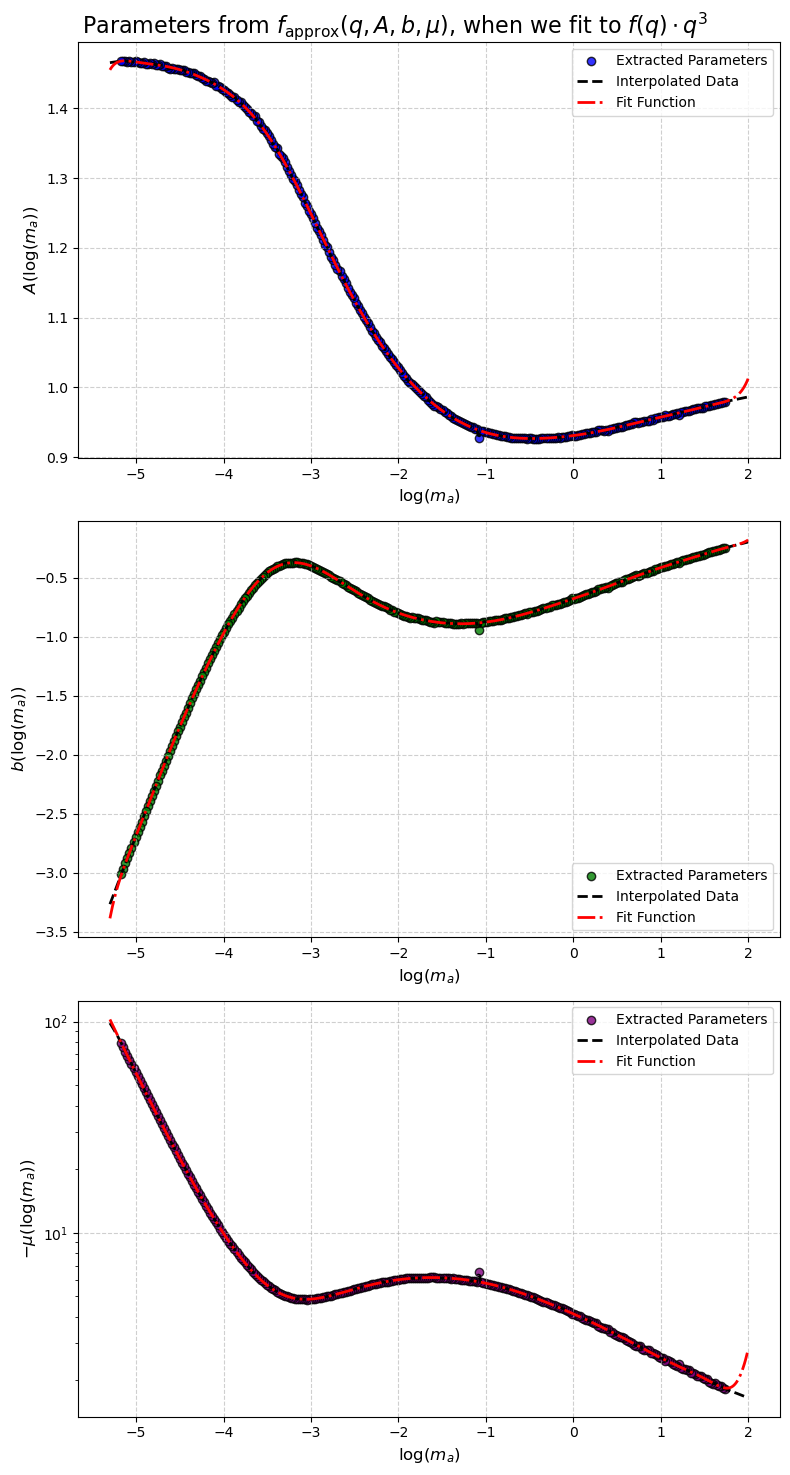

In [5]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^3$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q^2$

In [6]:
# --- DISTRIBUTION: f(q)*q^2 ---
distribution = "f(q)_q2"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -5.30  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 1.00192879e-07  2.61125459e-06  2.68746380e-05  1.29727058e-04
  2.11842419e-04 -5.78654254e-04 -2.63074163e-03 -1.04905399e-03
  8.03250941e-03  7.96087932e-03 -9.70972238e-03 -1.10866798e-02
 -6.15971229e-04  2.76580101e-02 -2.48689826e-02  8.86356626e-01]
Polynomial fit coefficients for b: [ 4.68783009e-07  1.14587321e-05  1.08545806e-04  4.59648050e-04
  4.63125969e-04 -2.86736764e-03 -8.39847796e-03  2.21540332e-03
  2.95653984e-02  1.20595062e-02 -4.15695486e-02 -2.09246417e-02
  8.38909788e-03  7.03162645e-02  5.73686307e-02 -8.75842945e-01]
Polynomial fit coefficients for μ: [ 8.39786068e-07  2.02929291e-05  1.88296861e-04  7.59149903e-04
  5.20851511e-04 -5.57356090e-03 -1.32476708e-02  1.02268742e-02
  5.07065923e-02 -2.22078403e-03 -7.06699877e-02  1.42060676e-03
 -4.40277044e-02  2.18339649e-01  5.82467149e-01 -5.37850726e+00]


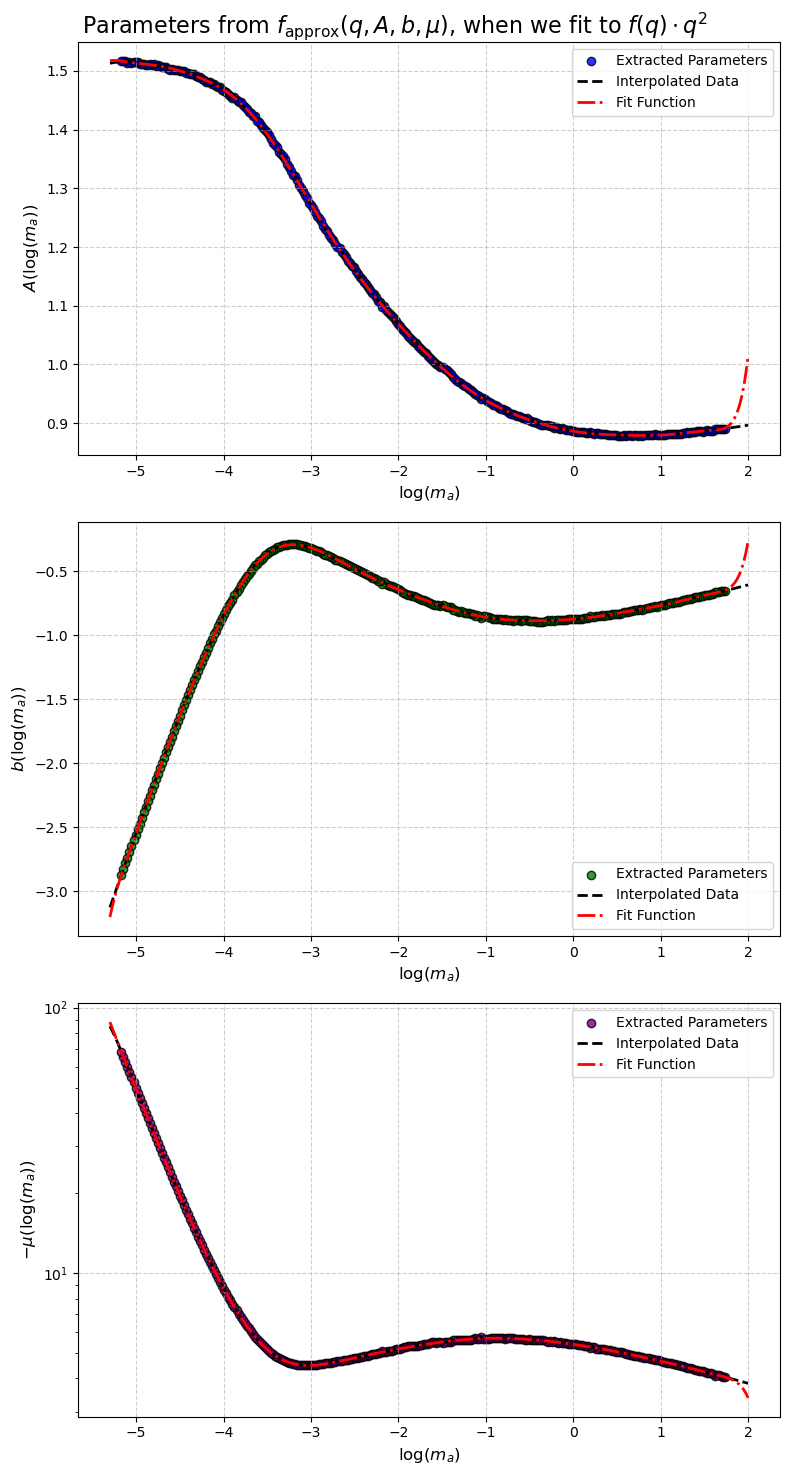

In [7]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^2$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q$

In [8]:
# --- DISTRIBUTION: f(q)*q ---
distribution = "f(q)_q1"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -5.30  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 3.32297547e-07  8.34043657e-06  8.20196990e-05  3.70471031e-04
  4.92711431e-04 -1.97293385e-03 -7.16395731e-03 -6.77476376e-04
  2.35737318e-02  1.72177863e-02 -3.21082162e-02 -2.92495663e-02
  1.85365280e-02  2.54405305e-02 -4.26318815e-02  6.45979696e-01]
Polynomial fit coefficients for b: [ 1.23096521e-06  3.00765236e-05  2.85430096e-04  1.21719666e-03
  1.28882681e-03 -7.36206354e-03 -2.22908319e-02  4.34458900e-03
  7.73724873e-02  3.80092631e-02 -1.10868686e-01 -7.36917462e-02
  6.90848889e-02  6.34889478e-02 -5.13953154e-02 -1.75423411e+00]
Polynomial fit coefficients for μ: [ 5.52740167e-06  1.30400071e-04  1.17883568e-03  4.61133737e-03
  2.89506631e-03 -3.30491163e-02 -7.60692999e-02  5.67559596e-02
  2.86189667e-01  2.52737725e-02 -4.36353793e-01 -1.42815976e-01
  2.95837101e-01  2.54438406e-01 -3.83025503e-02 -1.08366700e+01]


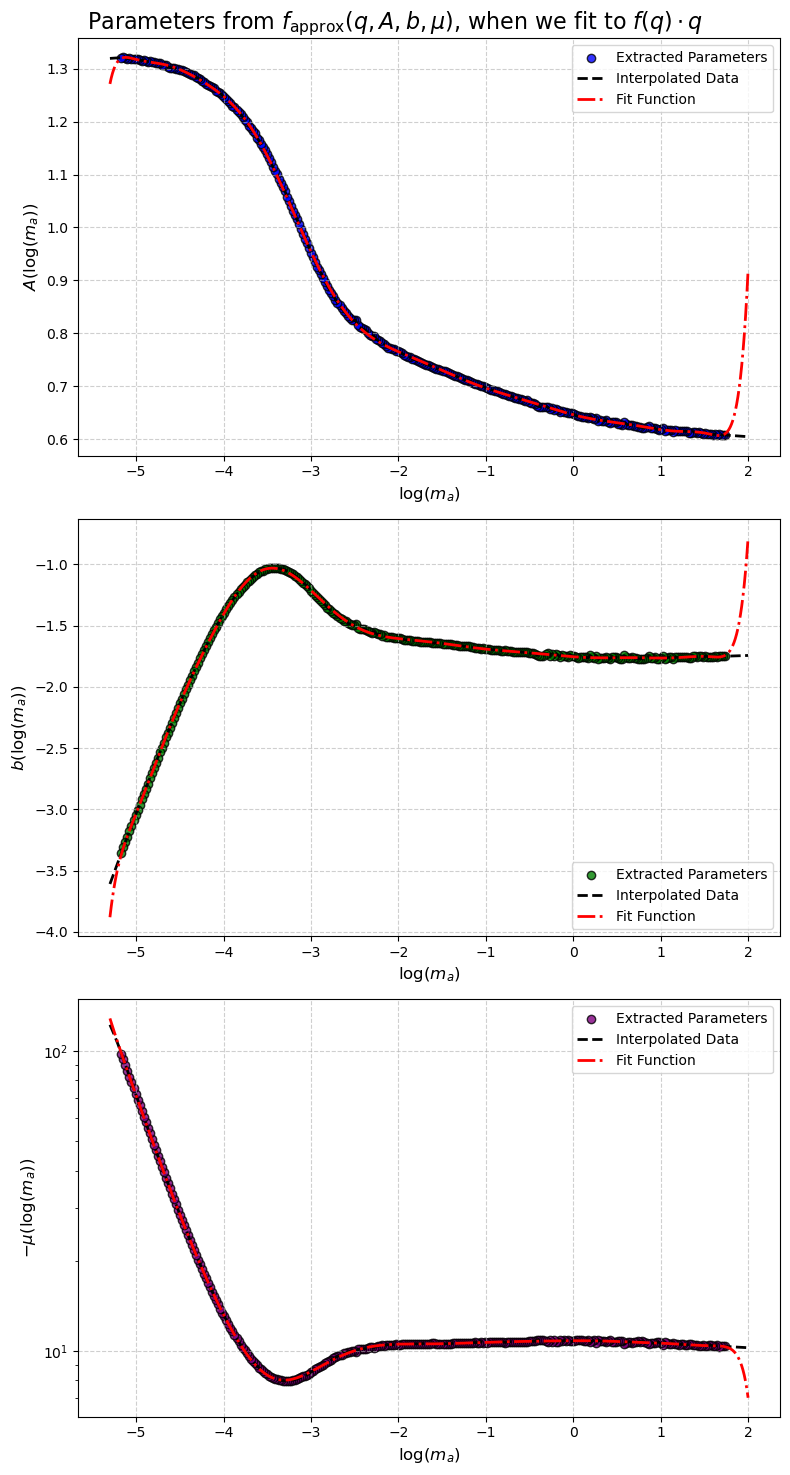

In [9]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)$

For now It does not work. But we do not have to take about. It just means, if we take f(q)*q^2 and multiply by q^(-2).
So in the end we will have f(q) and then we want comapre this to f_approx(q, A, b, mu) this comparison it not stable.
But the other is stable. We firstly compare f(q)*q^2 with f_approx(q, A, b, mu)*q^2 and then we multiply by q^(-2) and then
we obtain sth similar comparable with f(q).

In [10]:
# --- DISTRIBUTION: f(q) ---
distribution = "f(q)"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -5.30  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()